In [1]:
import pandas as pd 
import numpy as np 
from datetime import timedelta 
from sklearn.model_selection import StratifiedKFold 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression 
from sklearn.pipeline import Pipeline 
from sklearn.metrics import roc_auc_score

In [3]:
mld= pd.read_excel(r"C:\Users\Client\OneDrive - Queen Mary, University of London\PhD Shared folder\SomaScan Results\Soma results_T.xlsx", sheet_name='19 significant', parse_dates=["sample_date", "date_onset", "date_diagnostic", "date_of_birth", "death_date"])
mld.head()

,ID,group,sex,site_onset,date_of_birth,sample_date,age_visit,date_onset,date_diagnostic,diagnostic_delay,...,C5,TPP2,C3,TSC22D1,PLEC,TF,BCL2L1,EIF4A3,CHGB,NEFH
0,ALS F1,ALS,female,both,1935-09-18,2014-09-25,79,2014-04-01,2014-09-25,6.0,...,42199.3,2508.7,5595.3,1440.2,369.3,280155.5,3387.0,481.8,465.7,365.6
1,ALS F10,ALS,male,bulbar,1941-10-18,2015-08-13,73,2015-03-01,2015-07-30,5.0,...,42239.1,2486.0,8078.7,1444.6,359.2,287741.5,1481.0,467.9,518.8,976.5
2,ALS F11,ALS,male,limb,1937-01-27,2013-12-19,76,2010-01-01,2013-05-01,40.0,...,40077.5,900.9,4965.5,1057.7,747.9,245449.4,1274.1,510.1,603.4,345.0
3,ALS F12,ALS,male,limb,1946-06-11,2015-01-29,68,2014-05-01,2014-11-28,7.0,...,55141.6,1694.1,9078.8,1402.3,394.7,292660.8,2091.0,464.4,727.3,490.1
4,ALS F13,ALS,male,bulbar,1937-04-18,2017-06-28,80,2016-11-01,2017-06-01,7.0,...,38279.9,1134.9,3733.1,1457.0,437.4,252747.0,1946.1,466.0,672.5,364.6


In [4]:
#Identify protein columns (everything after clinical columns) 
clinical_cols = [ "ID", "group", "sex", "site_onset", "date_of_birth", "sample_date", "age_visit", "date_onset", "date_diagnostic", "diagnostic_delay",'age_onset', 'ALSFRSr', 'progression_rate', 'death_date', 'death_age', 'survival' ]

In [5]:
protein_cols = [c for c in mld.columns if c not in clinical_cols] 
print("Detected protein columns:", protein_cols[:10], "...")

Detected protein columns: ['TNR', 'APOL1', 'NUDT16L1', 'ISLR2', 'GSTP1', 'NRXN3', 'APOA4', 'DAZAP1', 'EHD2', 'C5'] ...


In [6]:
#Log2-transform protein values  # Add small constant to avoid log2(0) 
mld[protein_cols] = np.log2(mld[protein_cols] + 1)

In [7]:
#Encode site_of_onset (ALS only)
mld = pd.get_dummies(mld, columns=["site_onset"], prefix="site", drop_first=True)

In [8]:
#Compute time-to-death (years)  
def compute_time_to_death(row):
    if not pd.isna(row["death_date"]):
        return (row["death_date"] - row["sample_date"]).days / 30.44 # months
mld["time_to_death_months"] = mld.apply(compute_time_to_death, axis=1)

In [9]:
#Create death-within-X-months labels 
horizons_months = [6, 12, 24, 36, 60] # 0.5, 1, 2, 3, 5 years 
for H in horizons_months: mld[f"death_within_{H}m"] = (mld["time_to_death_months"] <= H).astype(int)

In [10]:
#Restrict to ALS patients for mortality prediction
df_als = mld[mld["group"] == "ALS"].copy()

In [11]:
# Define feature set
covariates = ["age_visit", "sex"] + [c for c in mld.columns if c.startswith("site_")]
feature_cols = protein_cols + covariates

# Convert sex to binary (if needed)
df_als["sex"] = df_als["sex"].map({"male": 1, "female": 0})

In [12]:
# Logistic regression CV function
def run_logistic_cv(data, feature_cols, label_col, n_splits=5):
    X = data[feature_cols].values
    y = data[label_col].values

    if y.sum() == 0 or y.sum() == len(y):
        print(f"{label_col}: only one class present, skipping.")
        return None

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l1",
            solver="saga",
            max_iter=5000,
            class_weight="balanced",
            C=1.0
        ))
    ])

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    aucs = []

    for train_idx, test_idx in cv.split(X, y):
        pipe.fit(X[train_idx], y[train_idx])
        y_pred = pipe.predict_proba(X[test_idx])[:, 1]
        aucs.append(roc_auc_score(y[test_idx], y_pred))

    return np.mean(aucs), np.std(aucs)

In [13]:
# Run models for each horizon
results = []

for H in horizons_months:
    label_col = f"death_within_{H}m"
    res = run_logistic_cv(df_als, feature_cols, label_col)

    if res:
        mean_auc, std_auc = res
        results.append({"horizon_months": H, "AUC": mean_auc, "SD": std_auc})
        print(f"{H} months: AUC = {mean_auc:.3f} ± {std_auc:.3f}")

results_df = pd.DataFrame(results)
print(results_df)

6 months: AUC = 0.550 ± 0.278
12 months: AUC = 0.726 ± 0.109
24 months: AUC = 0.821 ± 0.070
36 months: AUC = 0.771 ± 0.155
60 months: AUC = 0.965 ± 0.045
   horizon_months       AUC        SD
0               6  0.550000  0.277826
1              12  0.726333  0.108737
2              24  0.821429  0.069925
3              36  0.771429  0.154744
4              60  0.965278  0.045219


In [14]:
# Fit final model and inspect coefficients
H = 24  # example: 2-year mortality prediction
label_col = f"death_within_{H}m"

pipe_final = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="saga",
        max_iter=5000,
        class_weight="balanced",
        C=1.0
    ))
])

pipe_final.fit(df_als[feature_cols].values, df_als[label_col].values)

clf = pipe_final.named_steps["clf"]
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": clf.coef_[0]
}).sort_values("coef", key=np.abs, ascending=False)

print(coef_df.head(40))


        feature      coef
8          EHD2  1.874186
9            C5  1.452288
7        DAZAP1  0.905754
19    age_visit  0.637613
17         CHGB -0.614205
13         PLEC -0.429149
2      NUDT16L1 -0.426116
1         APOL1 -0.412527
22    site_limb -0.391327
12      TSC22D1 -0.306601
4         GSTP1 -0.265930
14           TF  0.129921
18         NEFH -0.081983
3         ISLR2 -0.004503
21  site_bulbar  0.000000
20          sex  0.000000
0           TNR  0.000000
16       EIF4A3  0.000000
15       BCL2L1  0.000000
10         TPP2  0.000000
6         APOA4  0.000000
5         NRXN3  0.000000
11           C3  0.000000


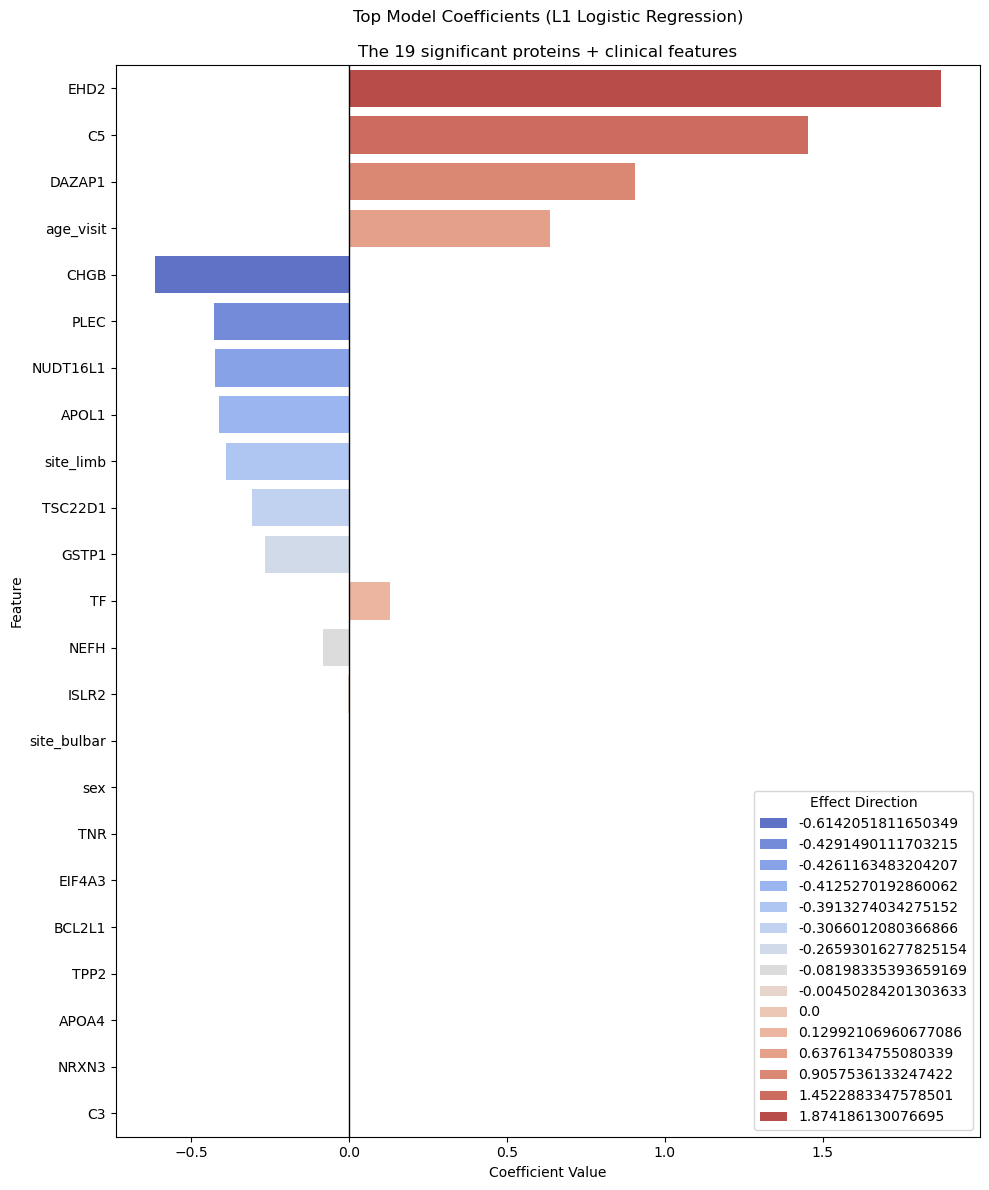

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by absolute coefficient size
coef_plot = coef_df.copy()
coef_plot["abs_coef"] = coef_plot["coef"].abs()
coef_plot = coef_plot.sort_values("abs_coef", ascending=False).head(25)  # top 25

# Assign colors based on sign
coef_plot["color"] = coef_plot["coef"].apply(lambda x: "Positive" if x > 0 else "Negative")

plt.figure(figsize=(10, 12))
sns.barplot(
    data=coef_plot,
    x="coef",
    y="feature",
    palette="coolwarm",
    hue="coef",
    dodge=False
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Top Model Coefficients (L1 Logistic Regression)\n \nThe 19 significant proteins + clinical features")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.legend(title="Effect Direction", loc="lower right")
plt.tight_layout()
plt.show()


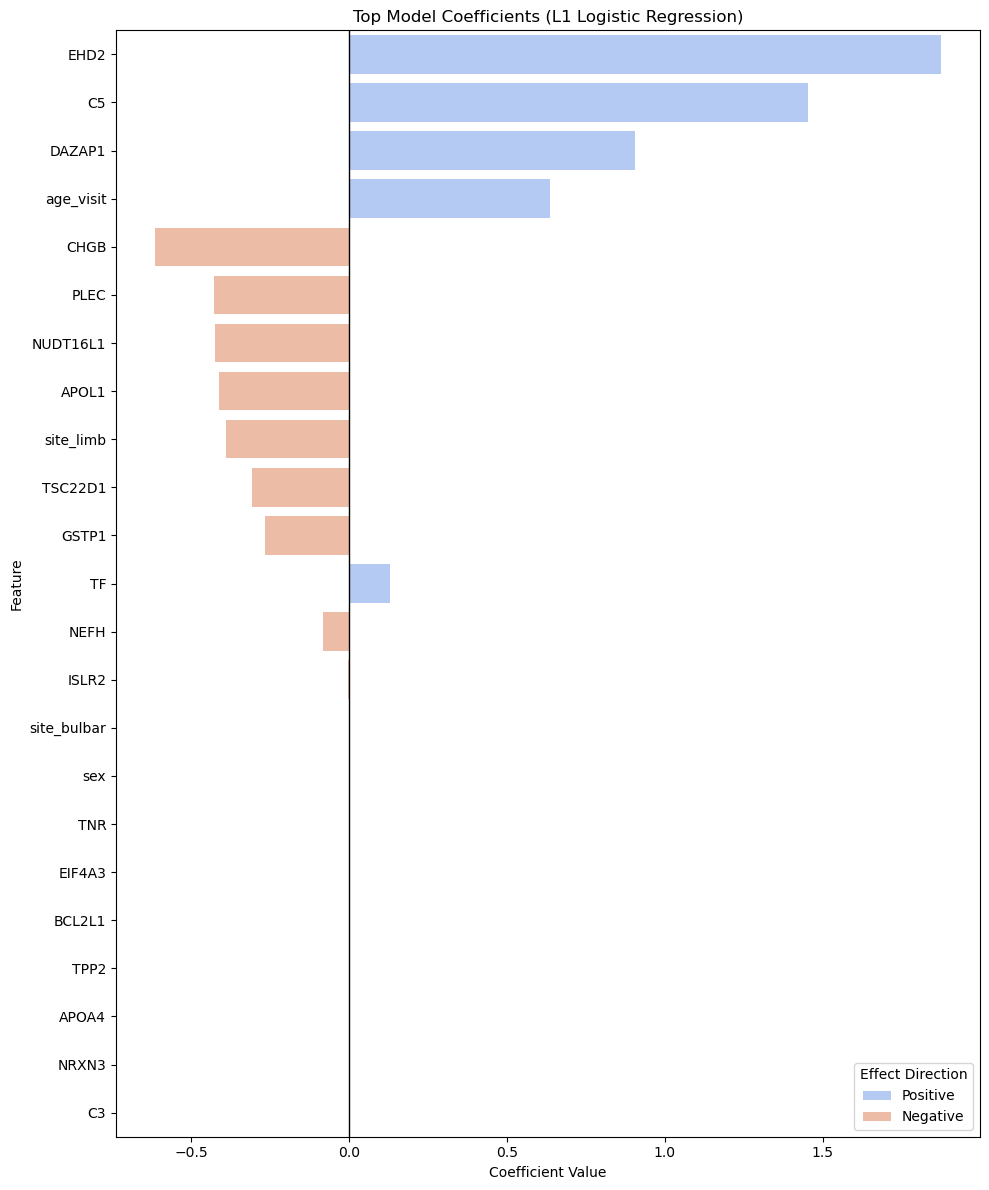

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort and select top features
coef_plot = coef_df.copy()
coef_plot["abs_coef"] = coef_plot["coef"].abs()
coef_plot = coef_plot.sort_values("abs_coef", ascending=False).head(25)

# Assign colors based on sign
coef_plot["color"] = coef_plot["coef"].apply(lambda x: "Positive" if x > 0 else "Negative")

plt.figure(figsize=(10, 12))
sns.barplot(
    data=coef_plot,
    x="coef",
    y="feature",
    hue="color",
    dodge=False,
    palette="coolwarm"
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Top Model Coefficients (L1 Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.legend(title="Effect Direction", loc="lower right")
plt.tight_layout()
plt.show()


In [28]:
# -----------------------------
# 1. Prepare data
# -----------------------------

# Feature matrix and label
X = df_als[feature_cols].values
y = df_als["death_within_24m"].values   # <-- choose your horizon here

# Logistic regression pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="saga",
        max_iter=5000,
        class_weight="balanced",
        C=1.0
    ))
])

# -----------------------------
# 2. Cross‑validated coefficient extraction
# -----------------------------

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
coef_list = []

for train_idx, test_idx in cv.split(X, y):
    pipe.fit(X[train_idx], y[train_idx])
    coef_list.append(pipe.named_steps["clf"].coef_[0])

coef_matrix = np.vstack(coef_list)

# -----------------------------
# 3. Compute stability metrics
# -----------------------------

coef_mean = coef_matrix.mean(axis=0)
coef_sd = coef_matrix.std(axis=0)
coef_cv = coef_sd / (np.abs(coef_mean) + 1e-8)   # coefficient of variation

stability_df = pd.DataFrame({
    "feature": feature_cols,
    "coef_mean": coef_mean,
    "coef_sd": coef_sd,
    "coef_cv": coef_cv,
    "abs_mean": np.abs(coef_mean)
}).sort_values("abs_mean", ascending=False)

# -----------------------------
# 4. Show top stable proteins
# -----------------------------

print("\nTop stable coefficients (largest absolute mean effect):")
print(stability_df.head(25))

# Optional: save to CSV
# stability_df.to_csv("coef_stability_24m.csv", index=False)



Top stable coefficients (largest absolute mean effect):
        feature  coef_mean   coef_sd   coef_cv  abs_mean
8          EHD2   1.607801  0.188919  0.117501  1.607801
9            C5   0.984169  0.496566  0.504553  0.984169
7        DAZAP1   0.659300  0.352366  0.534455  0.659300
19    age_visit   0.604474  0.288909  0.477951  0.604474
3         ISLR2  -0.410688  0.777486  1.893131  0.410688
2      NUDT16L1  -0.395980  0.230580  0.582303  0.395980
17         CHGB  -0.384980  0.302510  0.785783  0.384980
22    site_limb  -0.366864  0.240533  0.655646  0.366864
13         PLEC  -0.319691  0.190568  0.596100  0.319691
12      TSC22D1  -0.311873  0.248482  0.796742  0.311873
1         APOL1  -0.212436  0.159873  0.752571  0.212436
4         GSTP1  -0.151430  0.112106  0.740321  0.151430
14           TF   0.099040  0.168148  1.697774  0.099040
18         NEFH  -0.057636  0.241180  4.184524  0.057636
11           C3  -0.055350  0.110700  2.000000  0.055350
16       EIF4A3  -0.051290  0.1

In [23]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    recall_score,
    precision_score
)

def run_logistic_cv(data, feature_cols, label_col, n_splits=5):
    X = data[feature_cols].values
    y = data[label_col].values

    if y.sum() == 0 or y.sum() == len(y):
        print(f"{label_col}: only one class present, skipping.")
        return None

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l1",
            solver="saga",
            max_iter=5000,
            class_weight="balanced",
            C=1.0
        ))
    ])

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    aucs = []
    accs = []
    sens_list = []
    prec_list = []

    for train_idx, test_idx in cv.split(X, y):
        pipe.fit(X[train_idx], y[train_idx])
        y_pred = pipe.predict_proba(X[test_idx])[:, 1]
        y_pred_label = (y_pred > 0.5).astype(int)

        # Metrics
        aucs.append(roc_auc_score(y[test_idx], y_pred))
        accs.append(accuracy_score(y[test_idx], y_pred_label))
        sens_list.append(recall_score(y[test_idx], y_pred_label))
        prec_list.append(precision_score(y[test_idx], y_pred_label))

    return {
        "AUC_mean": np.mean(aucs),
        "AUC_sd": np.std(aucs),
        "ACC_mean": np.mean(accs),
        "SENS_mean": np.mean(sens_list),
        "PREC_mean": np.mean(prec_list)
    }



In [29]:
from sklearn.inspection import permutation_importance

r = permutation_importance(pipe_final, 
                           df_als[feature_cols], 
                           df_als[label_col],
                           n_repeats=20,
                           scoring="roc_auc")

perm_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": r.importances_mean
}).sort_values("importance", ascending=False)


C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warning

C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warning

C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warning

C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warning

C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warning

C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warning

C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warning

C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warning

In [30]:
from sklearn.utils import resample

boot_coefs = []

for i in range(200):
    boot = resample(df_als)
    pipe.fit(boot[feature_cols], boot[label_col])
    boot_coefs.append(pipe.named_steps["clf"].coef_[0])

boot_coefs = np.vstack(boot_coefs)

ci_df = pd.DataFrame({
    "feature": feature_cols,
    "coef_mean": boot_coefs.mean(axis=0),
    "coef_low": np.percentile(boot_coefs, 2.5, axis=0),
    "coef_high": np.percentile(boot_coefs, 97.5, axis=0)
})


In [32]:
# -------------------------------------------------------
# 1. Select horizon (e.g., 24 months)
# -------------------------------------------------------
H = 24
label_col = f"death_within_{H}m"

X = df_als[feature_cols].values
y = df_als[label_col].values

# -------------------------------------------------------
# 2. Define the model
# -------------------------------------------------------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="saga",
        max_iter=5000,
        class_weight="balanced",
        C=1.0
    ))
])

# -------------------------------------------------------
# 3. Cross‑validated coefficient extraction
# -------------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
coef_list = []

for train_idx, test_idx in cv.split(X, y):
    pipe.fit(X[train_idx], y[train_idx])
    coef_list.append(pipe.named_steps["clf"].coef_[0])

coef_matrix = np.vstack(coef_list)

# -------------------------------------------------------
# 4. Compute stability metrics
# -------------------------------------------------------
coef_mean = coef_matrix.mean(axis=0)
coef_sd = coef_matrix.std(axis=0)
coef_cv = coef_sd / (np.abs(coef_mean) + 1e-8)   # coefficient of variation

stability_df = pd.DataFrame({
    "feature": feature_cols,
    "coef_mean": coef_mean,
    "coef_sd": coef_sd,
    "coef_cv": coef_cv,
    "abs_mean": np.abs(coef_mean)
}).sort_values("abs_mean", ascending=False)

print("\nTop stable protein effects:")
print(stability_df.head(25))




Top stable protein effects:
        feature  coef_mean   coef_sd   coef_cv  abs_mean
8          EHD2   1.607770  0.188944  0.117519  1.607770
9            C5   0.984101  0.496604  0.504627  0.984101
7        DAZAP1   0.659216  0.352303  0.534427  0.659216
19    age_visit   0.604487  0.288981  0.478060  0.604487
3         ISLR2  -0.410763  0.777544  1.892927  0.410763
2      NUDT16L1  -0.396010  0.230663  0.582467  0.396010
17         CHGB  -0.384937  0.302458  0.785732  0.384937
22    site_limb  -0.366849  0.240550  0.655720  0.366849
13         PLEC  -0.319689  0.190554  0.596061  0.319689
12      TSC22D1  -0.311895  0.248528  0.796831  0.311895
1         APOL1  -0.212414  0.159866  0.752613  0.212414
4         GSTP1  -0.151392  0.112136  0.740701  0.151392
14           TF   0.099050  0.168169  1.697817  0.099050
18         NEFH  -0.057573  0.241329  4.191676  0.057573
11           C3  -0.055354  0.110708  2.000000  0.055354
16       EIF4A3  -0.051300  0.102600  2.000000  0.051300
20

In [24]:
for H in horizons_months:
    label_col = f"death_within_{H}m"
    res = run_logistic_cv(df_als, feature_cols, label_col)

    if res:
        print(f"\n{H} months:")
        for k, v in res.items():
            print(f"  {k}: {v:.3f}")



6 months:
  AUC_mean: 0.550
  AUC_sd: 0.278
  ACC_mean: 0.700
  SENS_mean: 0.300
  PREC_mean: 0.167

12 months:
  AUC_mean: 0.726
  AUC_sd: 0.109
  ACC_mean: 0.640
  SENS_mean: 0.660
  PREC_mean: 0.447

24 months:
  AUC_mean: 0.821
  AUC_sd: 0.070
  ACC_mean: 0.760
  SENS_mean: 0.762
  PREC_mean: 0.881

36 months:
  AUC_mean: 0.771
  AUC_sd: 0.155
  ACC_mean: 0.680
  SENS_mean: 0.743
  PREC_mean: 0.823


C:\Users\Client\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



60 months:
  AUC_mean: 0.965
  AUC_sd: 0.045
  ACC_mean: 0.860
  SENS_mean: 0.864
  PREC_mean: 0.978


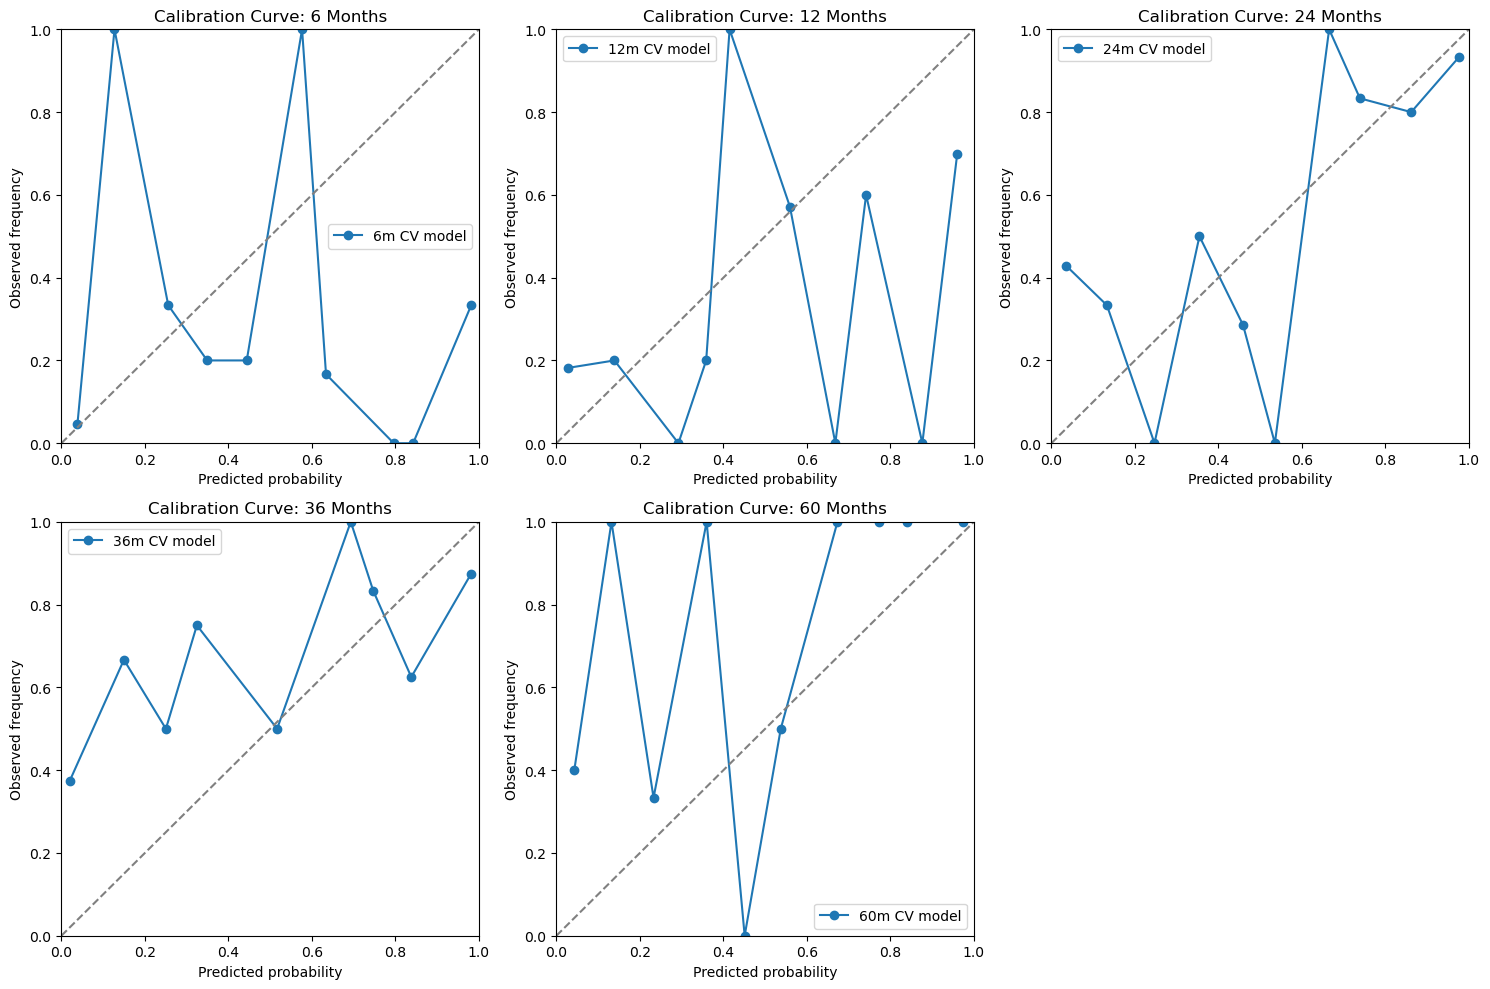

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Horizons you want to evaluate
horizons = [6, 12, 24, 36, 60]

# Create a multi-panel figure (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, H in enumerate(horizons):
    label_col = f"death_within_{H}m"

    X = df_als[feature_cols].values
    y = df_als[label_col].values

    # Model definition
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l1",
            solver="saga",
            max_iter=5000,
            class_weight="balanced",
            C=1.0
        ))
    ])

    # Cross-validation setup
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Store out-of-fold predictions
    oof_pred = np.zeros(len(y))

    for train_idx, test_idx in cv.split(X, y):
        pipe.fit(X[train_idx], y[train_idx])
        oof_pred[test_idx] = pipe.predict_proba(X[test_idx])[:, 1]

    # Compute calibration curve using OOF predictions
    prob_true, prob_pred = calibration_curve(y, oof_pred, n_bins=10)

    # Plot
    ax = axes[i]
    ax.plot(prob_pred, prob_true, marker='o', label=f"{H}m CV model")
    ax.plot([0, 1], [0, 1], '--', color='gray')
    ax.set_title(f"Calibration Curve: {H} Months")
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

# Hide last empty subplot if needed
if len(horizons) < len(axes):
    axes[-1].axis("off")

plt.tight_layout()
plt.show()


In [35]:
oof_pred = np.zeros(len(y))
for train_idx, test_idx in cv.split(X, y):
    pipe.fit(X[train_idx], y[train_idx])
    oof_pred[test_idx] = pipe.predict_proba(X[test_idx])[:, 1]

prob_true, prob_pred = calibration_curve(y, oof_pred, n_bins=10)


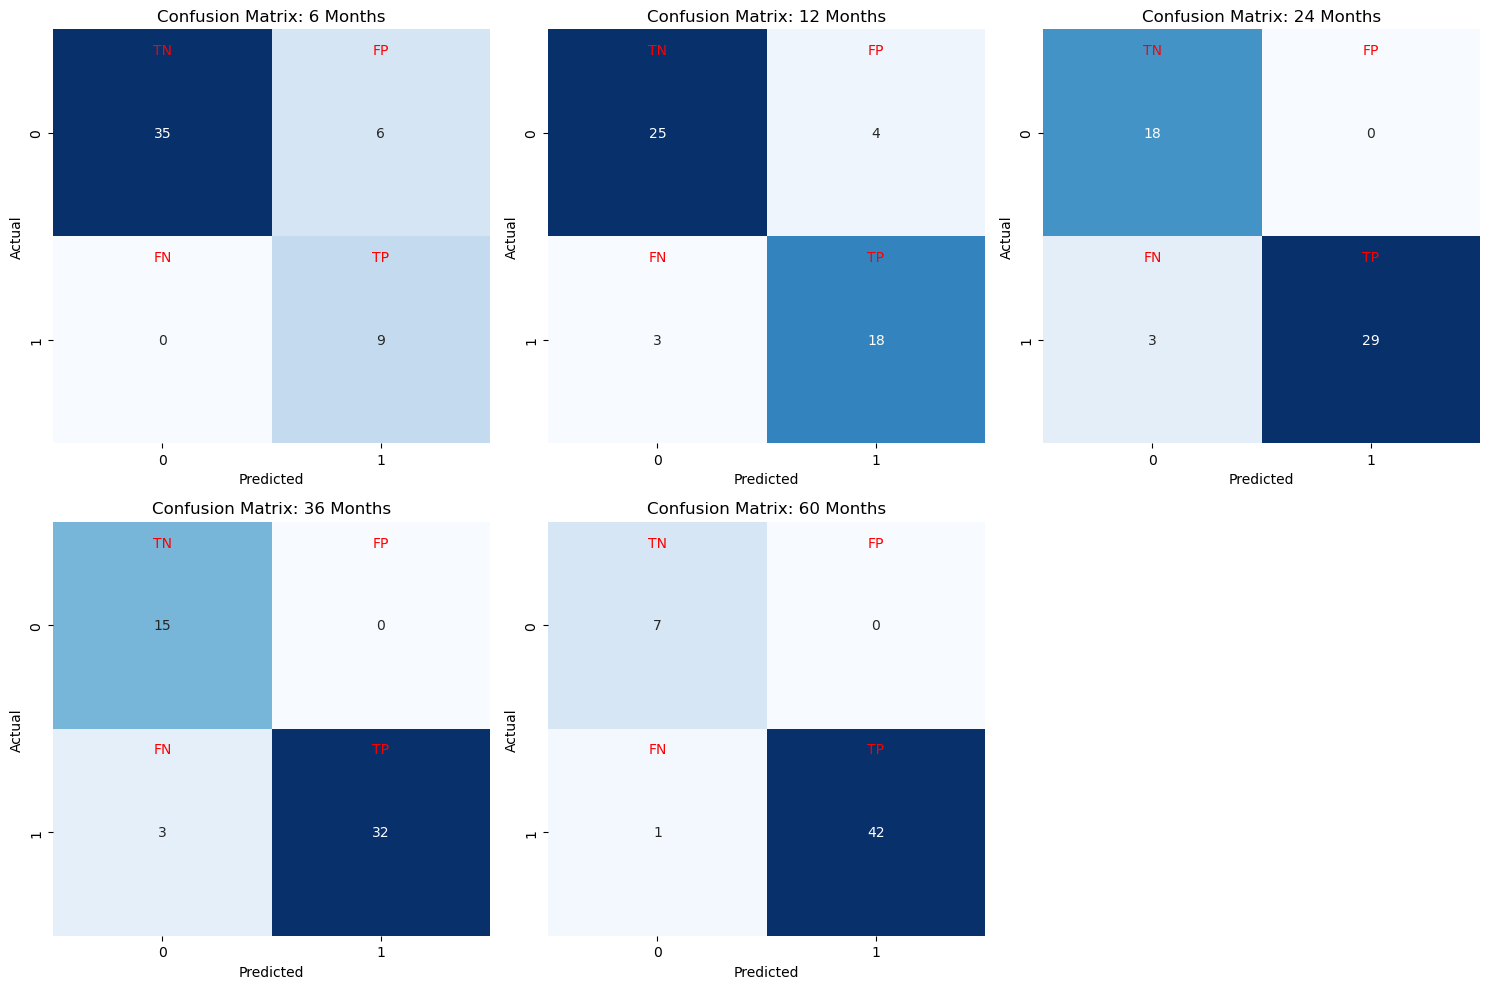

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Horizons to evaluate
horizons = [6, 12, 24, 36, 60]

# Create multi-panel figure
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, H in enumerate(horizons):
    label_col = f"death_within_{H}m"

    X = df_als[feature_cols].values
    y = df_als[label_col].values

    # Define model
    pipe_final = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l1",
            solver="saga",
            max_iter=5000,
            class_weight="balanced",
            C=1.0
        ))
    ])

    # Fit model
    pipe_final.fit(X, y)

    # Predict labels using 0.5 threshold
    y_pred_label = (pipe_final.predict_proba(X)[:, 1] > 0.5).astype(int)

    # Compute confusion matrix
    cm = confusion_matrix(y, y_pred_label)

    # Plot heatmap
    ax = axes[i]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)

    # Add TN, FP, FN, TP labels
    ax.text(0.5, 0.1, "TN", ha="center", va="center", fontsize=10, color="red")
    ax.text(1.5, 0.1, "FP", ha="center", va="center", fontsize=10, color="red")
    ax.text(0.5, 1.1, "FN", ha="center", va="center", fontsize=10, color="red")
    ax.text(1.5, 1.1, "TP", ha="center", va="center", fontsize=10, color="red")

    ax.set_title(f"Confusion Matrix: {H} Months")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

# Hide last empty subplot if needed
if len(horizons) < len(axes):
    axes[-1].axis("off")

plt.tight_layout()
plt.show()


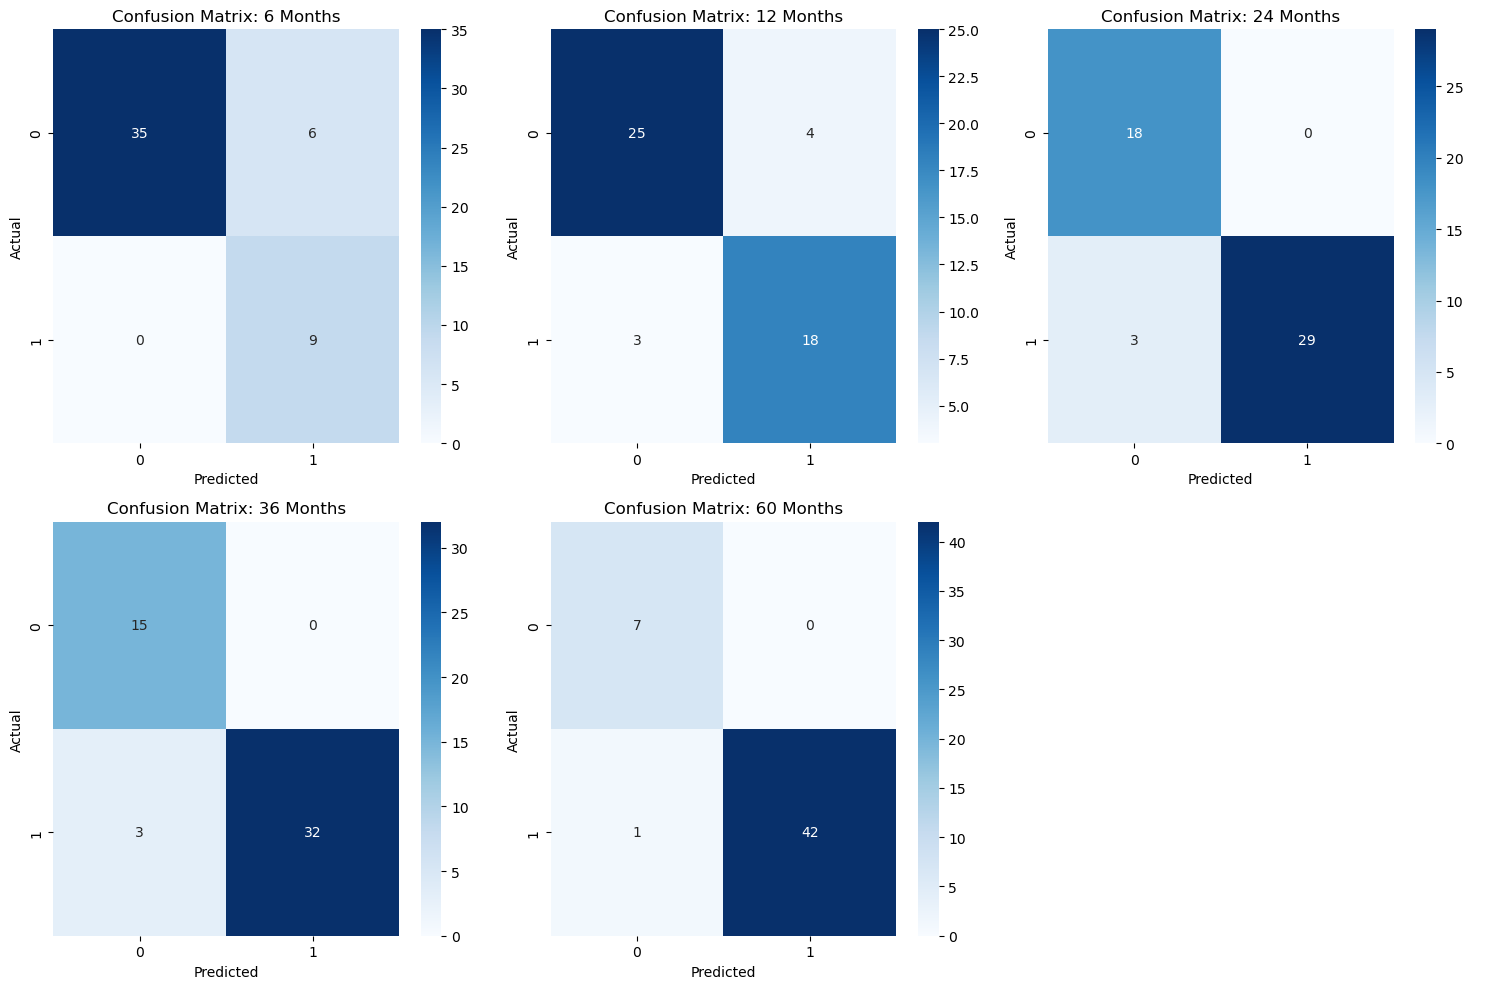

In [37]:
from sklearn.metrics import confusion_matrix


# Horizons to evaluate
horizons = [6, 12, 24, 36, 60]

# Create multi-panel figure
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, H in enumerate(horizons):
    label_col = f"death_within_{H}m"

    X = df_als[feature_cols].values
    y = df_als[label_col].values

    # Define model
    pipe_final = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l1",
            solver="saga",
            max_iter=5000,
            class_weight="balanced",
            C=1.0
        ))
    ])

    # Fit model
    pipe_final.fit(X, y)

    # Predict labels using 0.5 threshold
    y_pred_label = (pipe_final.predict_proba(X)[:, 1] > 0.5).astype(int)

    # Compute confusion matrix
    cm = confusion_matrix(y, y_pred_label)

    # Plot
    ax = axes[i]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"Confusion Matrix: {H} Months")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

# Hide last empty subplot if needed
if len(horizons) < len(axes):
    axes[-1].axis("off")

plt.tight_layout()
plt.show()


In [18]:
from sklearn.model_selection import train_test_split

horizons = [6, 12, 24, 36, 60]

trained_models = {}
X_test_dict = {}
y_test_dict = {}

for H in horizons:
    label_col = f"death_within_{H}m"

    # Skip horizons with only one class
    if df_als[label_col].nunique() < 2:
        print(f"Skipping {H} months — only one class present.")
        continue

    # Train/test split
    X = df_als[feature_cols].values
    y = df_als[label_col].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    # Build model
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l1",
            solver="saga",
            max_iter=5000,
            class_weight="balanced",
            C=1.0
        ))
    ])

    # Fit model
    pipe.fit(X_train, y_train)

    # Store everything
    trained_models[H] = pipe
    X_test_dict[H] = X_test
    y_test_dict[H] = y_test

    print(f"Trained model for {H} months.")


Trained model for 6 months.
Trained model for 12 months.
Trained model for 24 months.
Trained model for 36 months.
Trained model for 60 months.


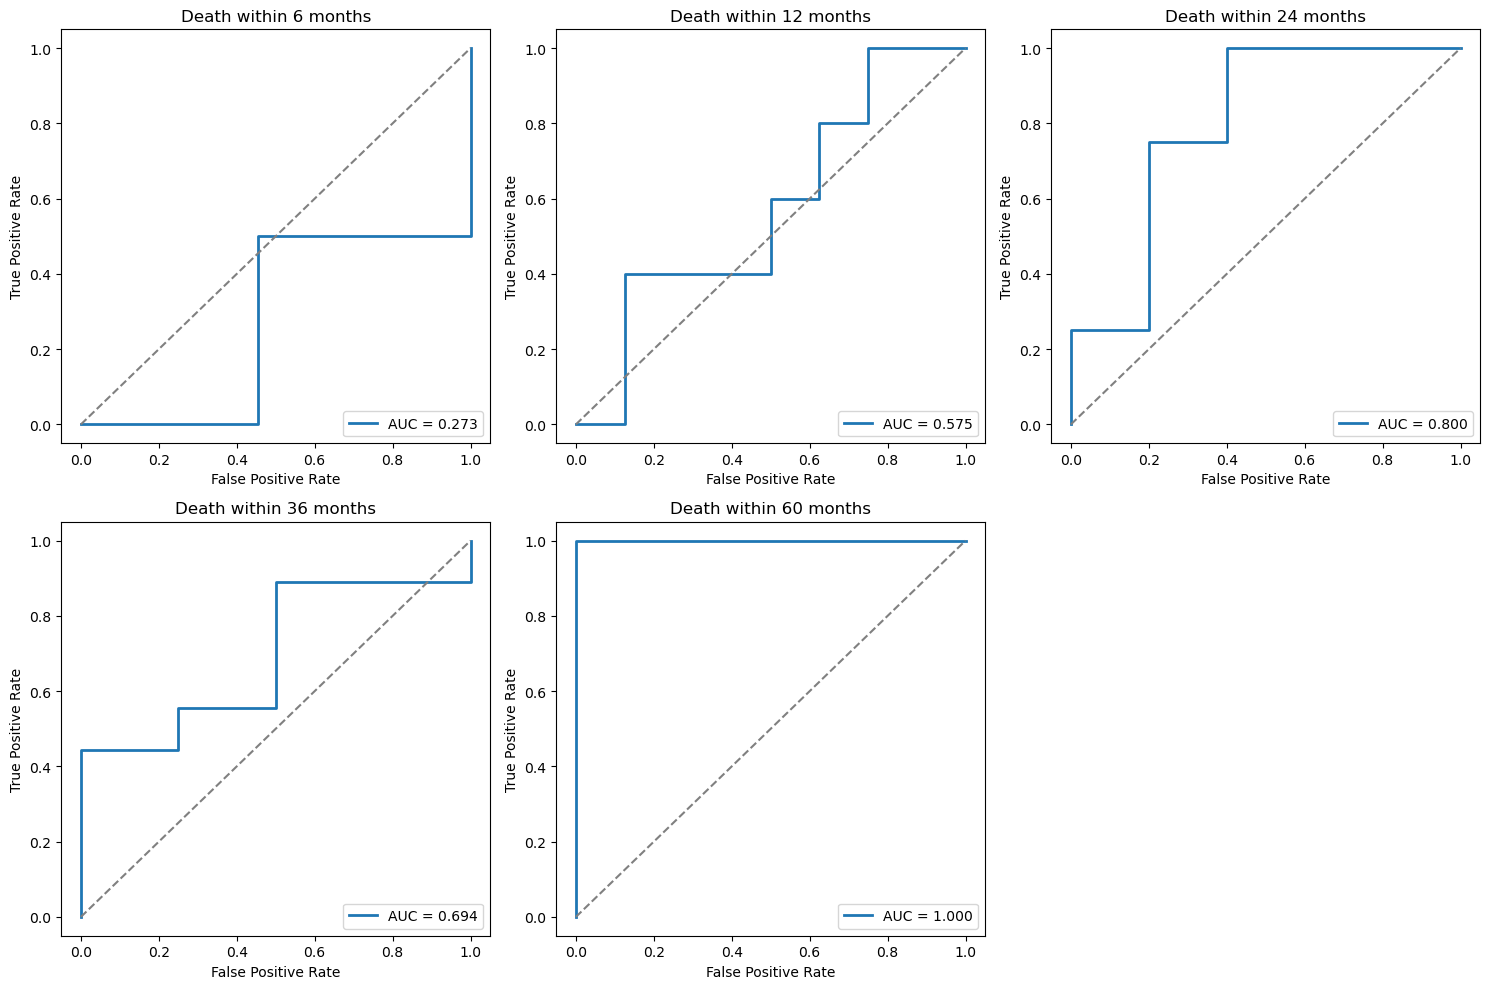

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# horizons and their models
horizons = [6, 12, 24, 36, 60]
models = {H: trained_models[H] for H in horizons}   # your dict of trained models
X_tests = {H: X_test_dict[H] for H in horizons}
y_tests = {H: y_test_dict[H] for H in horizons}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, H in enumerate(horizons):
    model = models[H]
    X_test = X_tests[H]
    y_test = y_tests[H]

    y_pred = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)

    ax = axes[i]
    ax.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")

    ax.set_title(f"Death within {H} months")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")

# Hide empty subplot if needed
axes[-1].axis("off")

plt.tight_layout()
plt.show()



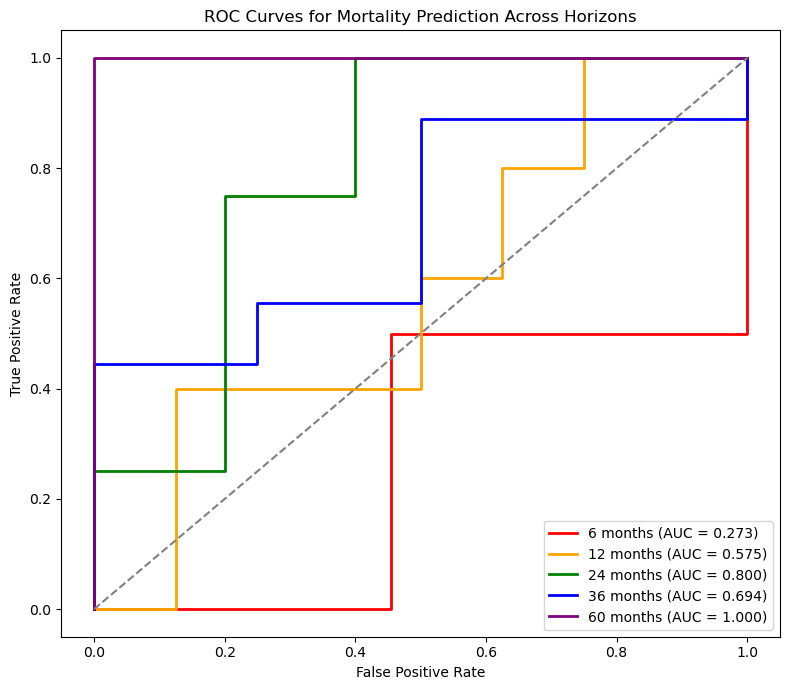

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 7))

colors = ["red", "orange", "green", "blue", "purple"]
horizons = [6, 12, 24, 36, 60]

for H, color in zip(horizons, colors):
    model = trained_models[H]
    X_test = X_test_dict[H]
    y_test = y_test_dict[H]

    y_pred = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, color=color,
             label=f"{H} months (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Mortality Prediction Across Horizons")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


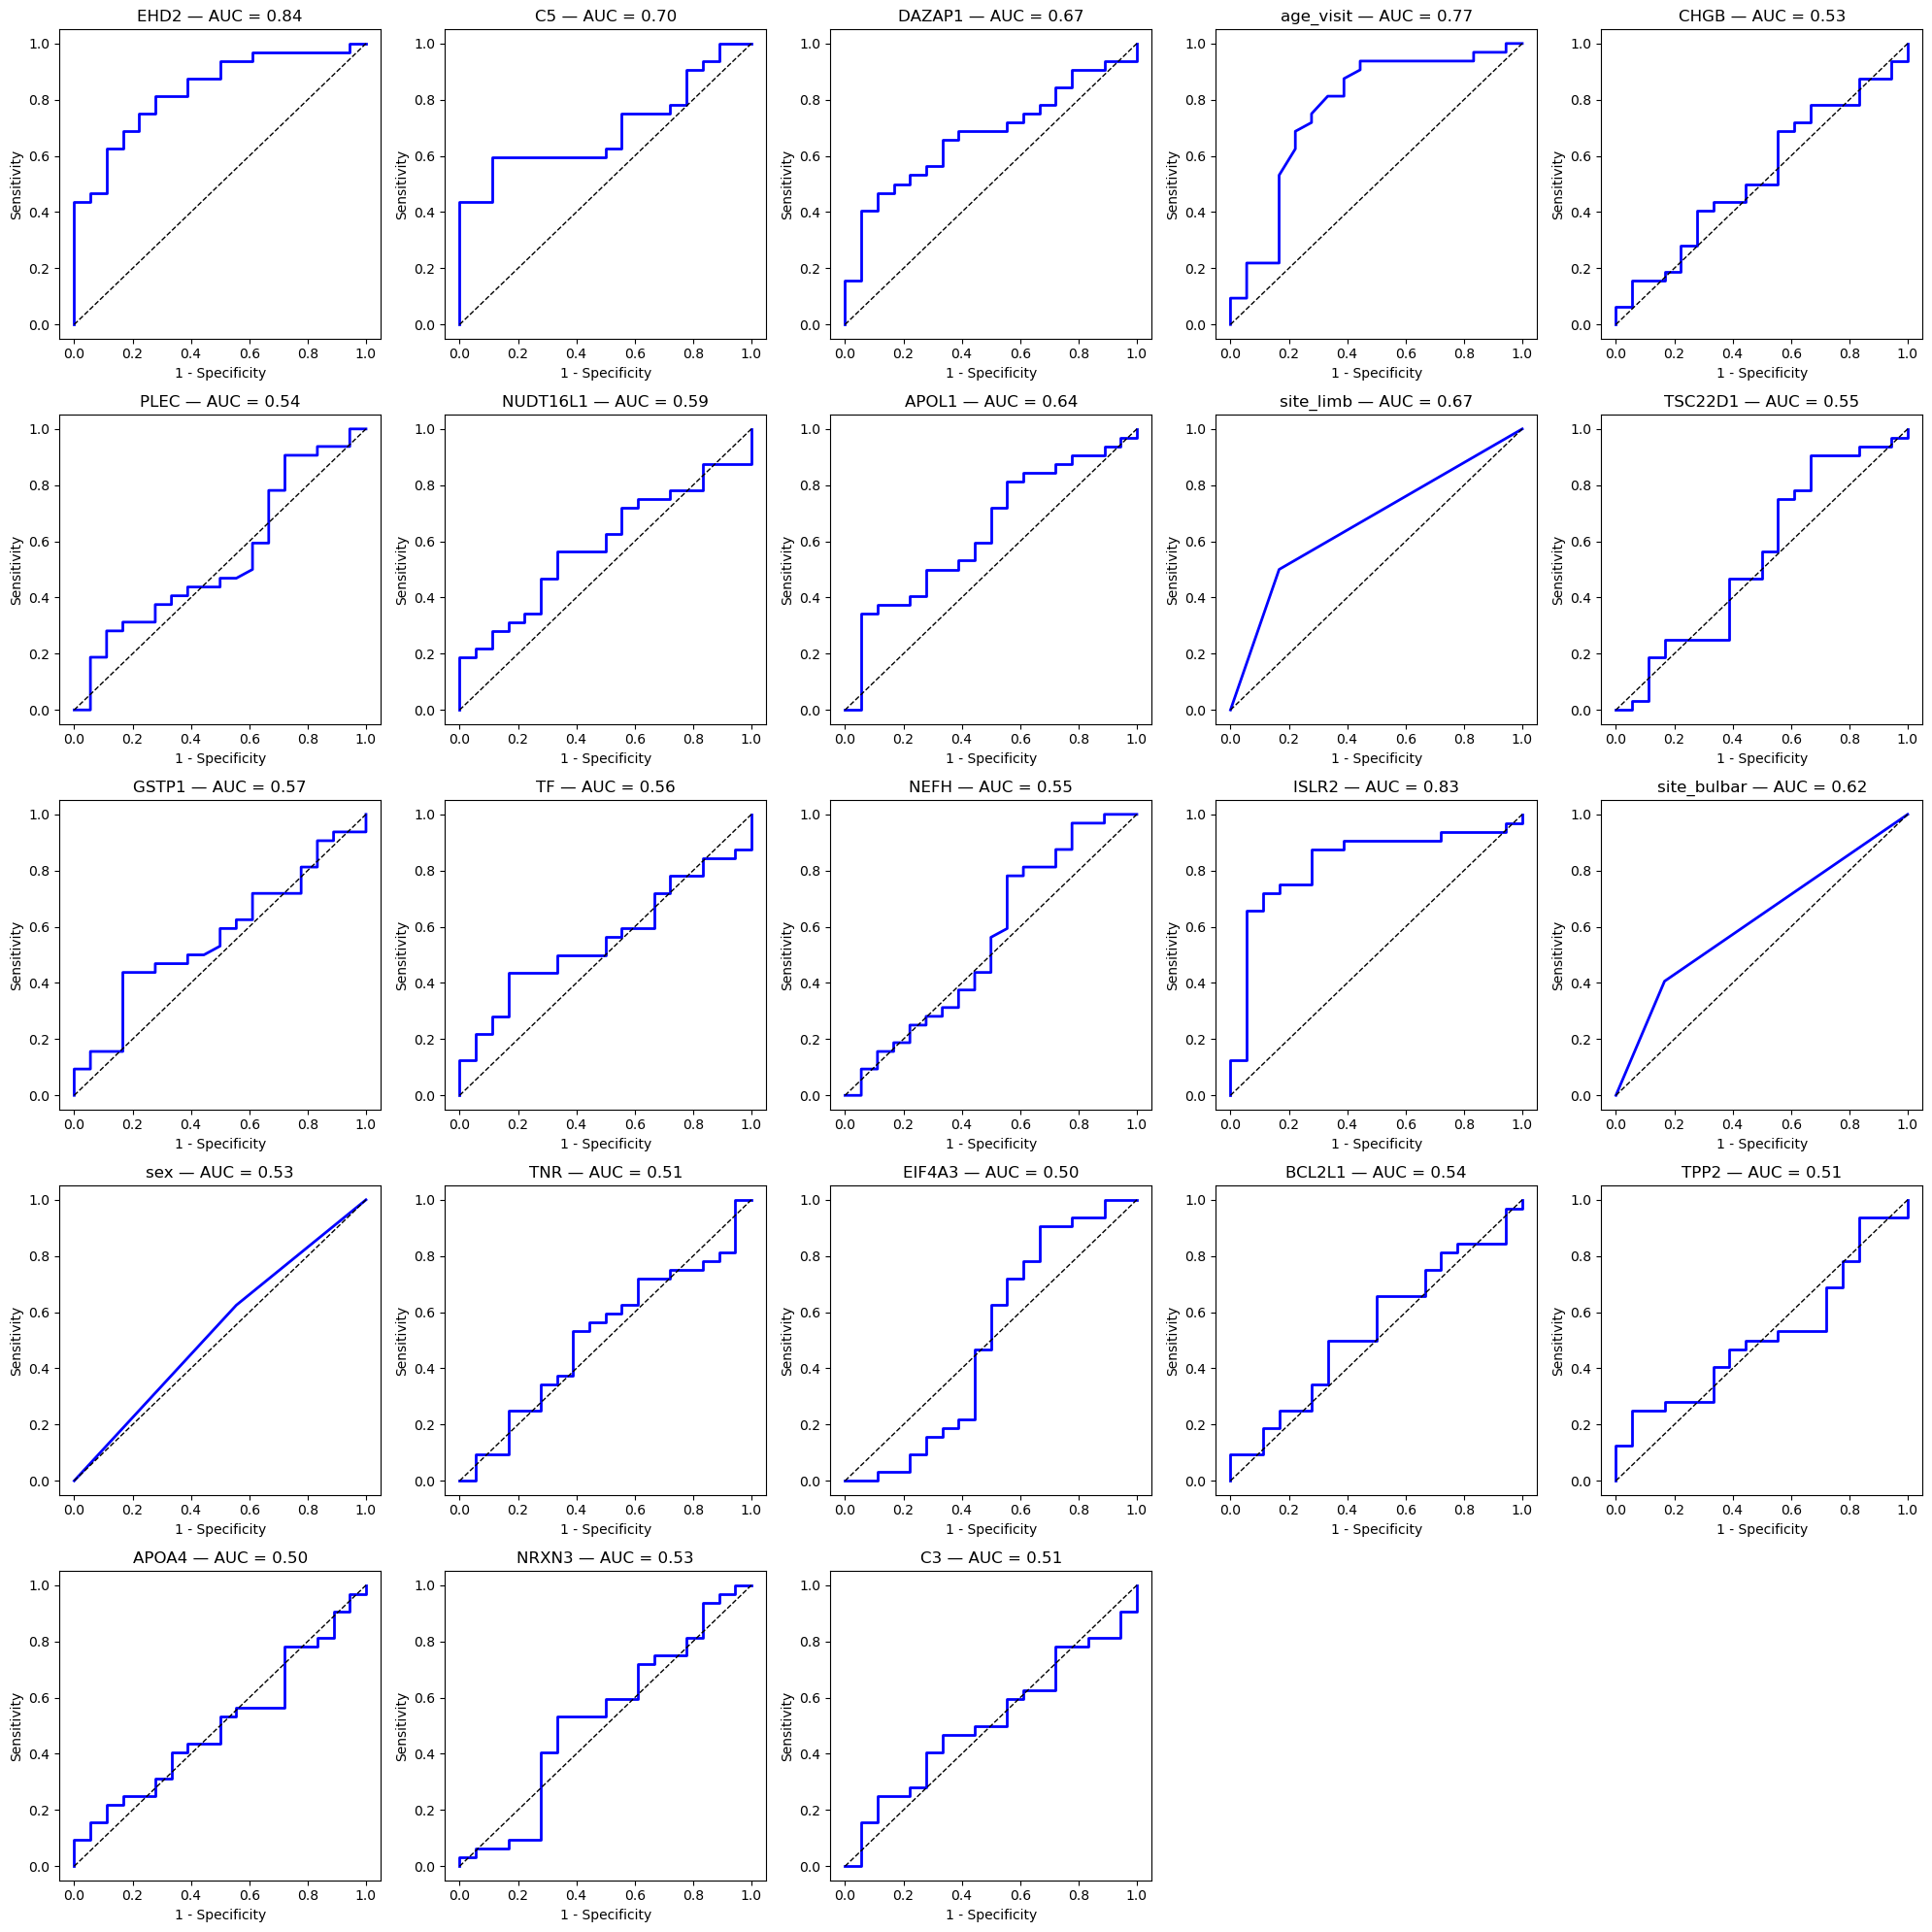

In [24]:
# ---------------------------------------------------------
# 1. Select top 19 features by absolute coefficient
# ---------------------------------------------------------
coef_df["abs_coef"] = coef_df["coef"].abs()
top14_features = coef_df.sort_values("abs_coef", ascending=False).head(23)["feature"].tolist()

# ---------------------------------------------------------
# 2. Setup plot grid
# ---------------------------------------------------------
n = len(top14_features)
cols = 5
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

# ---------------------------------------------------------
# 3. Loop through top 14 features and plot ROC
# ---------------------------------------------------------
label_col = "death_within_24m"  # adjust to your target horizon

for i, feature in enumerate(top14_features):
    # Prepare clean data
    df_feat = df_als[[feature, label_col]].replace([np.inf, -np.inf], np.nan).dropna()
    X = df_feat[[feature]].values
    y = df_feat[label_col].values

    # Skip if only one class
    if np.unique(y).size < 2:
        axes[i].axis("off")
        continue

    # Train logistic regression
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(penalty="none", solver="lbfgs", max_iter=1000))
    ])
    pipe.fit(X, y)
    y_pred = pipe.predict_proba(X)[:, 1]

    # Compute ROC
    fpr, tpr, _ = roc_curve(y, y_pred)
    roc_auc = auc(fpr, tpr)

    # Plot
    ax = axes[i]
    ax.plot(fpr, tpr, color="blue", lw=2)
    ax.plot([0, 1], [0, 1], linestyle="--", color="black", lw=1)
    ax.set_title(f"{feature} — AUC = {roc_auc:.2f}")
    ax.set_xlabel("1 - Specificity")
    ax.set_ylabel("Sensitivity")

# ---------------------------------------------------------
# 4. Hide unused subplots
# ---------------------------------------------------------
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


In [25]:

# ---------------------------------------------------------
# 1. Select top 19 features
# ---------------------------------------------------------
coef_df["abs_coef"] = coef_df["coef"].abs()
top19_features = coef_df.sort_values("abs_coef", ascending=False).head(23)["feature"].tolist()

# ---------------------------------------------------------
# 2. Compute AUC for each feature
# ---------------------------------------------------------
label_col = "death_within_24m"  # adjust to your target horizon
auc_list = []

for feature in top19_features:
    df_feat = df_als[[feature, label_col]].replace([np.inf, -np.inf], np.nan).dropna()
    X = df_feat[[feature]].values
    y = df_feat[label_col].values

    if np.unique(y).size < 2:
        auc_list.append({"feature": feature, "AUC": np.nan})
        continue

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(penalty="none", solver="lbfgs", max_iter=1000))
    ])
    pipe.fit(X, y)
    y_pred = pipe.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_pred)
    roc_auc = auc(fpr, tpr)

    auc_list.append({"feature": feature, "AUC": round(roc_auc, 3)})

# ---------------------------------------------------------
# 3. Create and display table
# ---------------------------------------------------------
auc_df = pd.DataFrame(auc_list)
print(auc_df.sort_values("AUC", ascending=False))


        feature    AUC
0          EHD2  0.835
13        ISLR2  0.828
3     age_visit  0.766
1            C5  0.696
2        DAZAP1  0.674
8     site_limb  0.667
7         APOL1  0.635
14  site_bulbar  0.620
6      NUDT16L1  0.585
10        GSTP1  0.567
11           TF  0.557
12         NEFH  0.549
9       TSC22D1  0.545
5          PLEC  0.543
18       BCL2L1  0.542
15          sex  0.535
4          CHGB  0.531
21        NRXN3  0.526
16          TNR  0.514
19         TPP2  0.512
22           C3  0.512
20        APOA4  0.502
17       EIF4A3  0.500


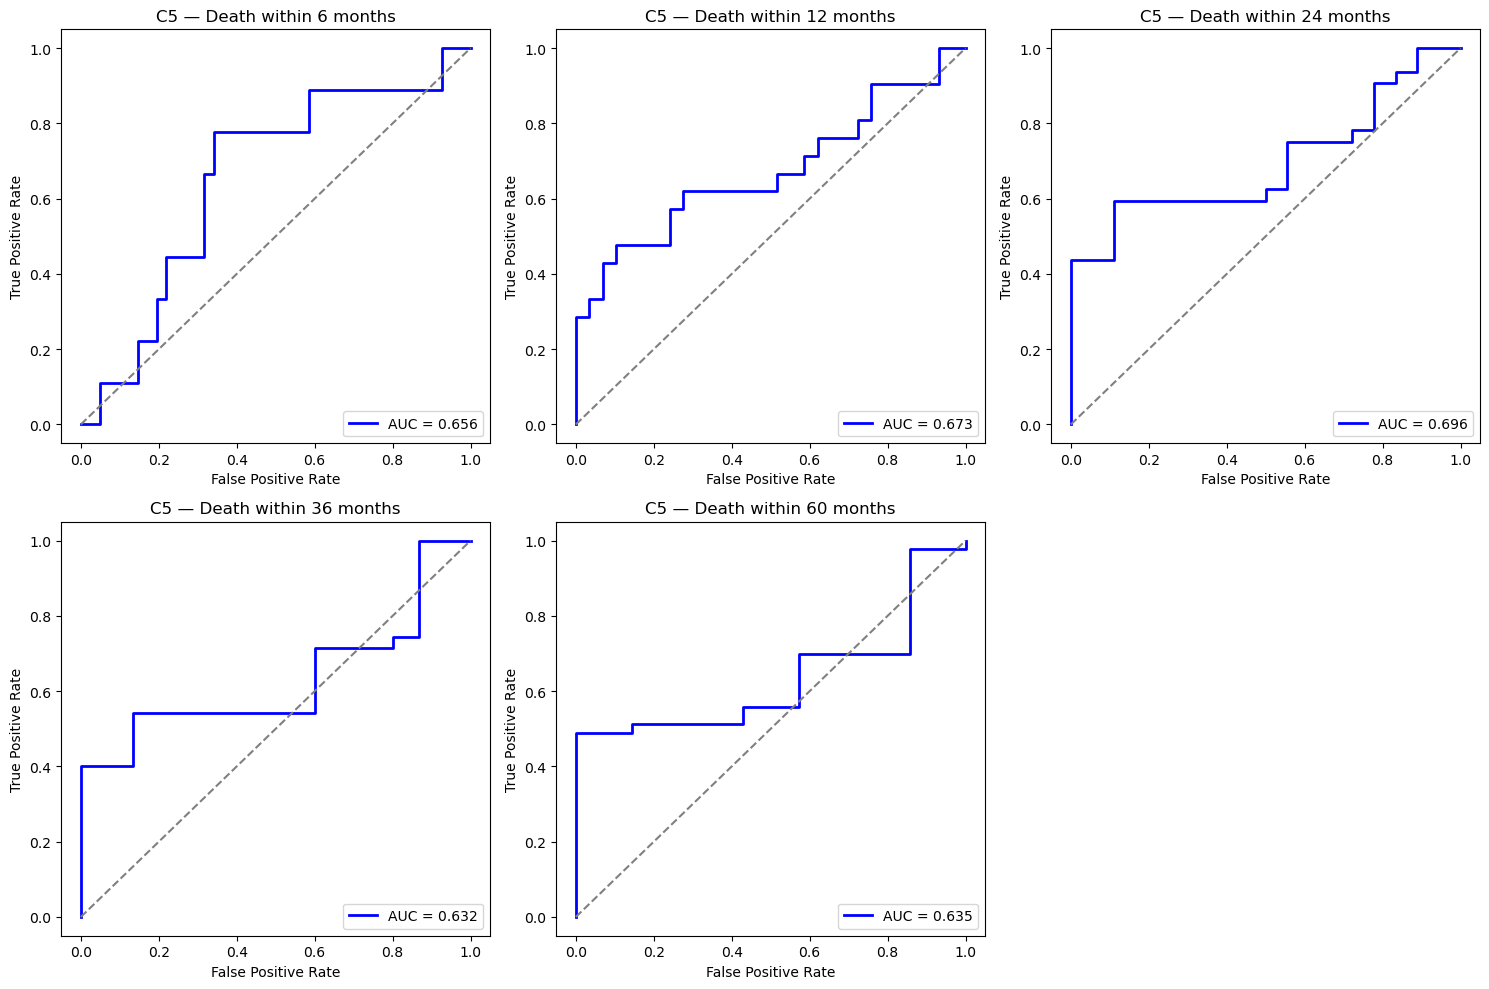

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

# Horizons you want to evaluate
horizons = [6, 12, 24, 36, 60]

# Prepare figure
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, H in enumerate(horizons):
    label_col = f"death_within_{H}m"

    # Skip if horizon has only one class
    if df_als[label_col].nunique() < 2:
        axes[i].set_title(f"{H} months — insufficient data")
        axes[i].axis("off")
        continue

    # Extract clean data for C5
    df_feat = df_als[["C5", label_col]].replace([np.inf, -np.inf], np.nan).dropna()
    X = df_feat[["C5"]].values
    y = df_feat[label_col].values

    # Skip if still only one class
    if np.unique(y).size < 2:
        axes[i].set_title(f"{H} months — one class only")
        axes[i].axis("off")
        continue

    # Build logistic regression model
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="none",
            solver="lbfgs",
            max_iter=2000
        ))
    ])

    # Fit model
    pipe.fit(X, y)

    # Predict probabilities
    y_pred = pipe.predict_proba(X)[:, 1]

    # Compute ROC
    fpr, tpr, _ = roc_curve(y, y_pred)
    roc_auc = auc(fpr, tpr)

    # Plot
    ax = axes[i]
    ax.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}", color="blue")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")

    ax.set_title(f"C5 — Death within {H} months")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")

# Hide unused subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()


In [27]:
summary = {}

for H in horizons:
    col = f"death_within_{H}m"
    counts = df_als[col].value_counts(dropna=True)
    summary[H] = {
        "alive": counts.get(0, 0),
        "dead": counts.get(1, 0),
        "total": counts.sum()
    }

pd.DataFrame(summary).T


,alive,dead,total
6,41,9,50
12,29,21,50
24,18,32,50
36,15,35,50
60,7,43,50


In [28]:
for H in horizons:
    col = f"death_within_{H}m"
    n = df_als[col].dropna().shape[0]
    print(f"{H} months: {n} patients with valid data")


6 months: 50 patients with valid data
12 months: 50 patients with valid data
24 months: 50 patients with valid data
36 months: 50 patients with valid data
60 months: 50 patients with valid data


In [29]:
df_als["death_0_6"]   = (df_als["time_to_death_months"] <= 6).astype(int)
df_als["death_6_12"]  = ((df_als["time_to_death_months"] > 6) &
                         (df_als["time_to_death_months"] <= 12)).astype(int)
df_als["death_12_24"] = ((df_als["time_to_death_months"] > 12) &
                         (df_als["time_to_death_months"] <= 24)).astype(int)
df_als["death_24_36"] = ((df_als["time_to_death_months"] > 24) &
                         (df_als["time_to_death_months"] <= 36)).astype(int)
df_als["death_36_60"] = ((df_als["time_to_death_months"] > 36) &
                         (df_als["time_to_death_months"] <= 60)).astype(int)


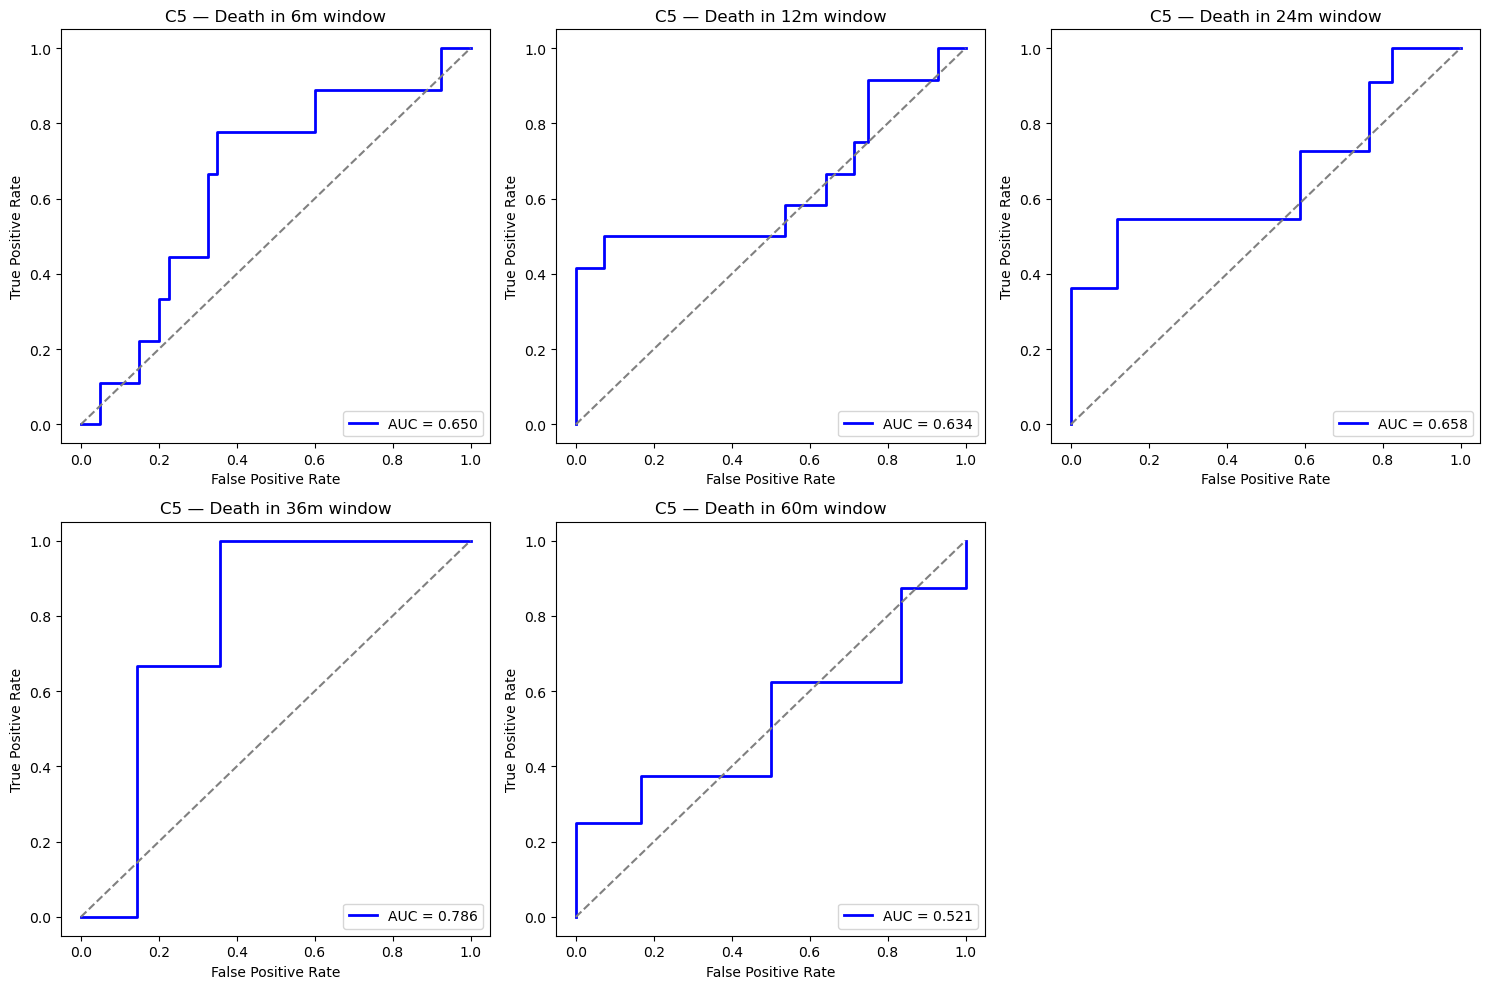

In [30]:

horizon_labels = {
    6:  "death_0_6",
    12: "death_6_12",
    24: "death_12_24",
    36: "death_24_36",
    60: "death_36_60"
}

# --- 2. ROC analysis for each non-overlapping window ---

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, H in enumerate([6, 12, 24, 36, 60]):
    label_col = horizon_labels[H]

    # CASES = patients who died in this window
    cases = df_als[df_als[label_col] == 1]

    # CONTROLS = patients who survived beyond this window
    controls = df_als[df_als["time_to_death_months"] > H]

    # Combine
    df_feat = pd.concat([cases, controls], axis=0)

    # Clean
    df_feat = df_feat[["C5", label_col]].replace([np.inf, -np.inf], np.nan).dropna()

    # Skip if insufficient data
    if df_feat[label_col].nunique() < 2:
        axes[i].set_title(f"{H}m — insufficient data")
        axes[i].axis("off")
        continue

    X = df_feat[["C5"]].values
    y = df_feat[label_col].values

    # Model
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="none",
            solver="lbfgs",
            max_iter=2000
        ))
    ])

    pipe.fit(X, y)
    y_pred = pipe.predict_proba(X)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y, y_pred)
    roc_auc = auc(fpr, tpr)

    # Plot
    ax = axes[i]
    ax.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}", color="blue")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")

    ax.set_title(f"C5 — Death in {H}m window")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")

# Hide last empty subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()


C:\Users\Client\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1183: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1183: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1183: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1183: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(
C:\Users\Client\anaconda3\lib\site-packages\sklearn\linear_m

Skipping 60+ — insufficient data


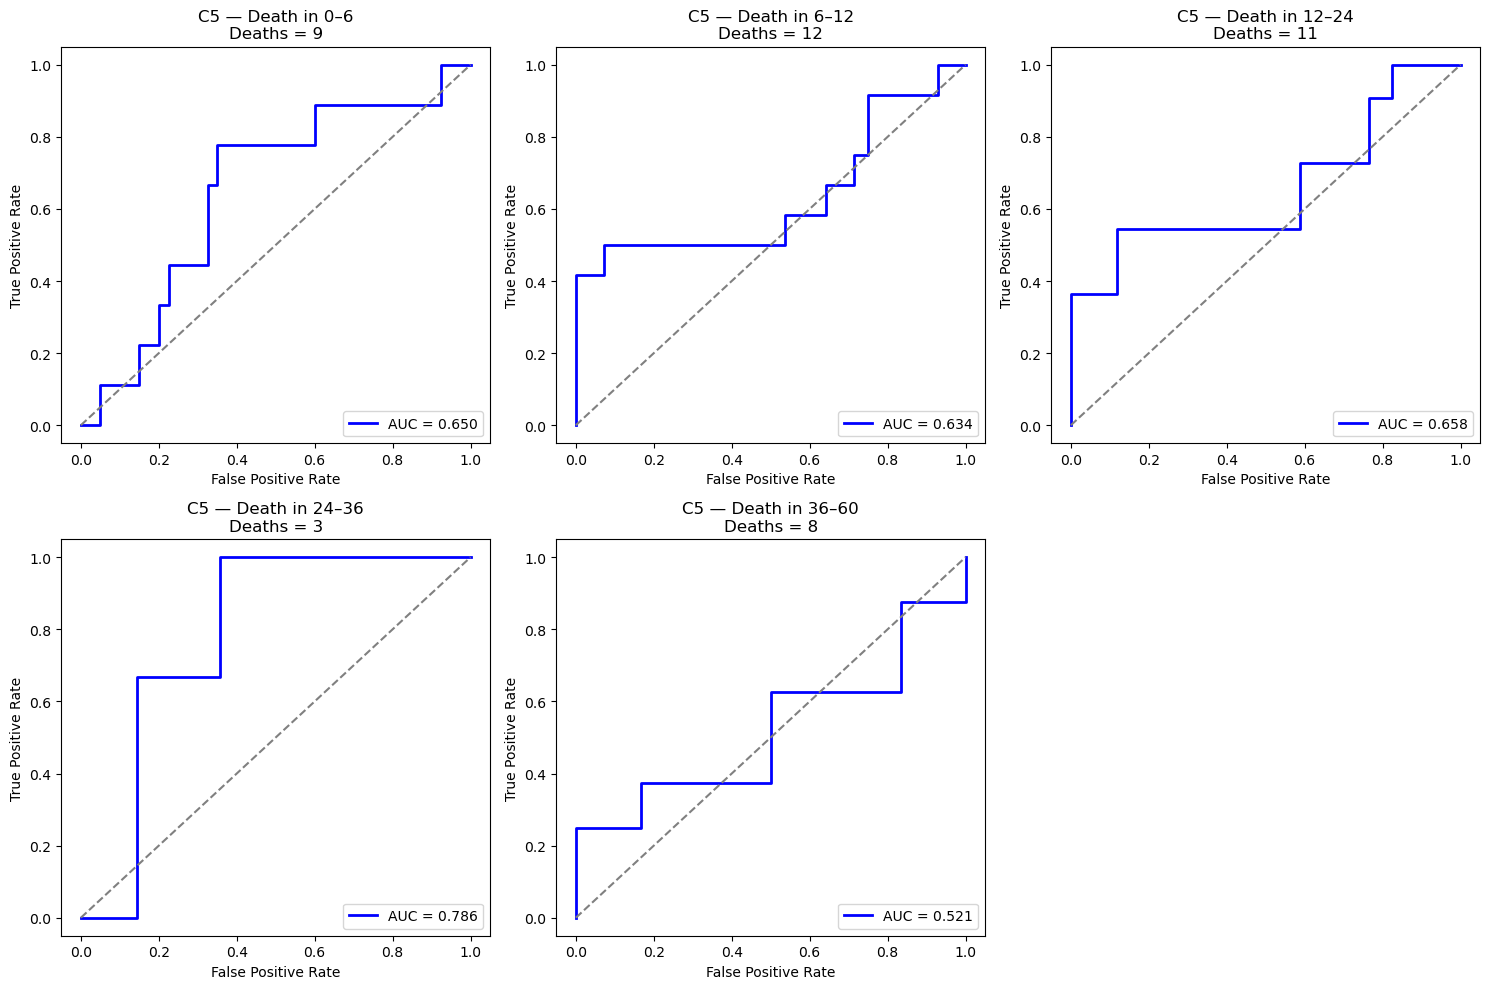

In [42]:
# --- 1. Create mutually exclusive death windows ---

df_als["death_0_6"] = (df_als["time_to_death_months"] <= 6).astype(int)
df_als["death_6_12"] = ((df_als["time_to_death_months"] > 6) &
                        (df_als["time_to_death_months"] <= 12)).astype(int)
df_als["death_12_24"] = ((df_als["time_to_death_months"] > 12) &
                         (df_als["time_to_death_months"] <= 24)).astype(int)
df_als["death_24_36"] = ((df_als["time_to_death_months"] > 24) &
                         (df_als["time_to_death_months"] <= 36)).astype(int)
df_als["death_36_60"] = ((df_als["time_to_death_months"] > 36) &
                         (df_als["time_to_death_months"] <= 60)).astype(int)
df_als["death_60_inf"] = (df_als["time_to_death_months"] > 60).astype(int)

# Horizon mapping
horizon_labels = {
    "0–6":  "death_0_6",
    "6–12": "death_6_12",
    "12–24": "death_12_24",
    "24–36": "death_24_36",
    "36–60": "death_36_60",
    "60+":   "death_60_inf"
}

# --- 2. ROC analysis for each non-overlapping window ---

fig = plt.figure(figsize=(15, 10))
plot_index = 1  # counter for valid subplots

for label, col in horizon_labels.items():

    # CASES = died in this window
    cases = df_als[df_als[col] == 1]

    # CONTROLS = survived beyond the upper bound of the window
    if label == "0–6":
        controls = df_als[df_als["time_to_death_months"] > 6]
    elif label == "6–12":
        controls = df_als[df_als["time_to_death_months"] > 12]
    elif label == "12–24":
        controls = df_als[df_als["time_to_death_months"] > 24]
    elif label == "24–36":
        controls = df_als[df_als["time_to_death_months"] > 36]
    elif label == "36–60":
        controls = df_als[df_als["time_to_death_months"] > 60]
    else:  # 60+
        controls = pd.DataFrame(columns=df_als.columns)  # empty

    # Combine
    df_feat = pd.concat([cases, controls], axis=0)
    df_feat = df_feat[["C5", col]].replace([np.inf, -np.inf], np.nan).dropna()

    # Skip windows with insufficient data
    if df_feat[col].nunique() < 2:
        print(f"Skipping {label} — insufficient data")
        continue

    # --- Plot only valid windows ---
    ax = fig.add_subplot(2, 3, plot_index)
    plot_index += 1

    X = df_feat[["C5"]].values
    y = df_feat[col].values

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="none",
            solver="lbfgs",
            max_iter=2000
        ))
    ])

    pipe.fit(X, y)
    y_pred = pipe.predict_proba(X)[:, 1]

    fpr, tpr, _ = roc_curve(y, y_pred)
    roc_auc = auc(fpr, tpr)

    n_deaths = cases.shape[0]

    ax.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}", color="blue")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")

    ax.set_title(f"C5 — Death in {label}\nDeaths = {n_deaths}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()


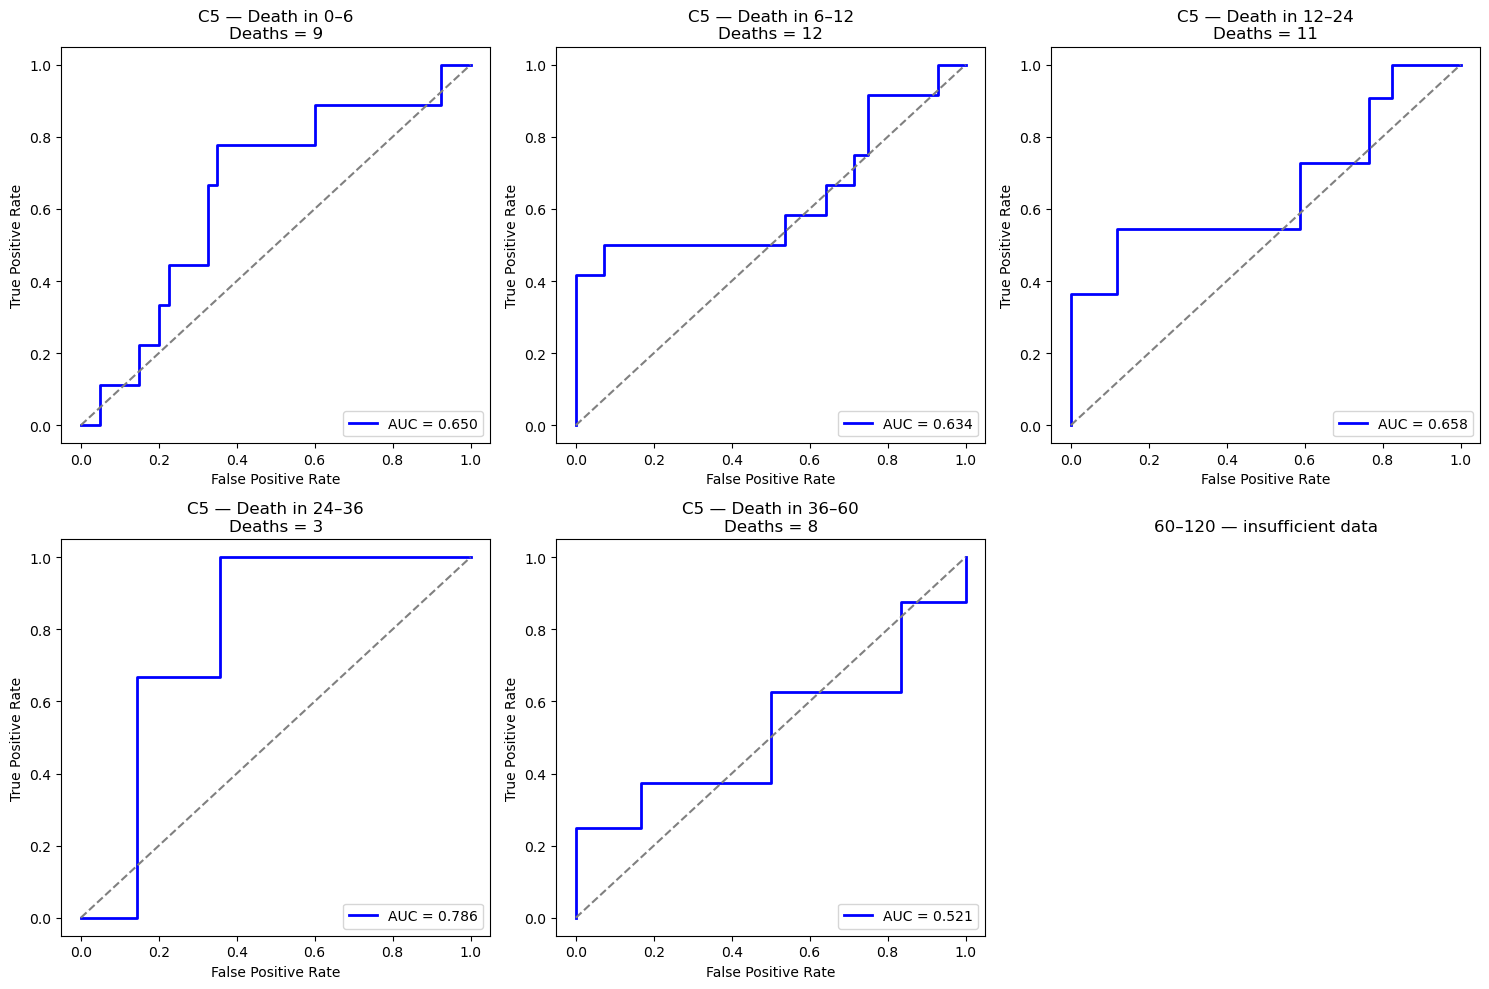

In [35]:
# --- 1. Create mutually exclusive death windows ---

df_als["death_0_6"] = (df_als["time_to_death_months"] <= 6).astype(int)
df_als["death_6_12"] = ((df_als["time_to_death_months"] > 6) &
                        (df_als["time_to_death_months"] <= 12)).astype(int)
df_als["death_12_24"] = ((df_als["time_to_death_months"] > 12) &
                         (df_als["time_to_death_months"] <= 24)).astype(int)
df_als["death_24_36"] = ((df_als["time_to_death_months"] > 24) &
                         (df_als["time_to_death_months"] <= 36)).astype(int)
df_als["death_36_60"] = ((df_als["time_to_death_months"] > 36) &
                         (df_als["time_to_death_months"] <= 60)).astype(int)
df_als["death_60_120"] = ((df_als["time_to_death_months"] > 60) &
                          (df_als["time_to_death_months"] <= 120)).astype(int)

# Horizon mapping
horizon_labels = {
    "0–6":  "death_0_6",
    "6–12": "death_6_12",
    "12–24": "death_12_24",
    "24–36": "death_24_36",
    "36–60": "death_36_60",
    "60–120": "death_60_120"
}

# --- 2. ROC analysis for each non-overlapping window ---

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (label, col) in enumerate(horizon_labels.items()):

    # CASES = died in this window
    cases = df_als[df_als[col] == 1]

    # CONTROLS = survived beyond the upper bound of the window
    if label == "0–6":
        controls = df_als[df_als["time_to_death_months"] > 6]
    elif label == "6–12":
        controls = df_als[df_als["time_to_death_months"] > 12]
    elif label == "12–24":
        controls = df_als[df_als["time_to_death_months"] > 24]
    elif label == "24–36":
        controls = df_als[df_als["time_to_death_months"] > 36]
    elif label == "36–60":
        controls = df_als[df_als["time_to_death_months"] > 60]
    elif label == "60–120":
        controls = df_als[df_als["time_to_death_months"] > 120]
    else:
        controls = pd.Data
    # Combine
    df_feat = pd.concat([cases, controls], axis=0)

    # Clean
    df_feat = df_feat[["C5", col]].replace([np.inf, -np.inf], np.nan).dropna()

    # Skip if insufficient data
    if df_feat[col].nunique() < 2:
        axes[i].set_title(f"{label} — insufficient data")
        axes[i].axis("off")
        continue

    X = df_feat[["C5"]].values
    y = df_feat[col].values

    # Model
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="none",
            solver="lbfgs",
            max_iter=2000
        ))
    ])

    pipe.fit(X, y)
    y_pred = pipe.predict_proba(X)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y, y_pred)
    roc_auc = auc(fpr, tpr)

    # Plot
    ax = axes[i]
    ax.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}", color="blue")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")

    # Count deaths in this window
    n_deaths = cases.shape[0]

    ax.set_title(f"C5 — Death in {label}\nDeaths = {n_deaths}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()
